### 남산 타워사진을 고흐 스타일로 바꾸어보자

In [38]:
import os
import math
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

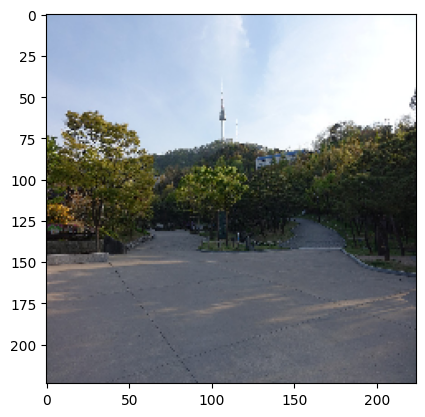

In [39]:
contents = cv2.imread('dataset/GAN/contents.jpg')
contents = cv2.resize(contents,(224,224))
plt.imshow(cv2.cvtColor(contents,cv2.COLOR_BGR2RGB))

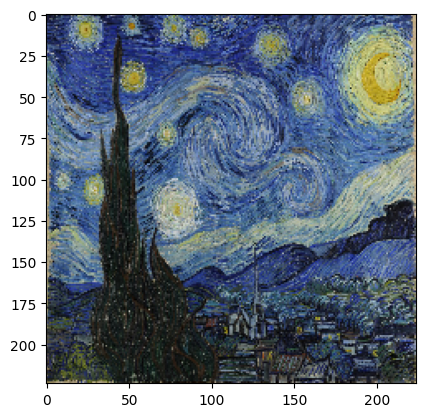

In [40]:
style = cv2.imread('dataset/GAN/style.jpg')
style = cv2.resize(style,(224,224))
plt.imshow(cv2.cvtColor(style,cv2.COLOR_BGR2RGB))

In [41]:
# VGG16을 이용해서 이미지의 중간 특징맵을 뽑아낼려고 함.

vgg_model = tf.keras.applications.VGG16(input_shape=(224,224,3),
                                        include_top = False,
                                        weights='imagenet')
vgg_model.trainable = False

In [42]:
# VGG16 중간층 4개의 출력만 가져온다.
# block1 (얕은 층) : 간단한 질감, 선, 색
# block2,3 (중간 층) : 패턴, 모양, 질감
# block4 (깊은 층) : 복잡한, 구조, 형태

style_transfer_model = tf.keras.Model(
    inputs=vgg_model.input,
    outputs=[
        vgg_model.get_layer(name="block1_conv2").output,
        vgg_model.get_layer(name="block2_conv2").output,
        vgg_model.get_layer(name="block3_conv3").output,
        vgg_model.get_layer(name="block4_conv3").output
    ]
)

style_transfer_model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

In [43]:
style_true_b1c1 , style_true_b2c2 , style_true_b3c3 , style_true_b4c3 = style_transfer_model.predict(
    np.reshape(style, (-1,224,224,3)))

style_true_b1c1.shape

1/1 [==============================] - 0s 82ms/step


(1, 224, 224, 64)

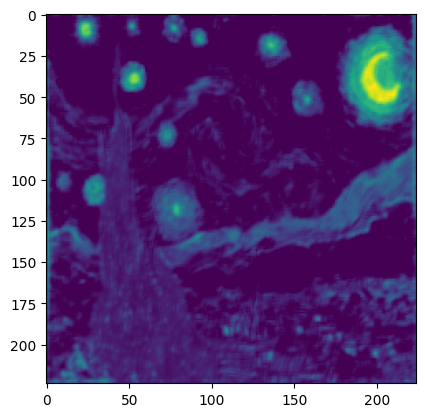

In [44]:
# 이미지의 부분중 밝게 나올수록 필터가 강하게 저용되는 부분임을 알 수 있다.

plt.imshow(style_true_b1c1[0][:,:,60])

In [45]:
contents_true_b1c1 , contents_true_b2c2 , contents_true_b3c3 , contents_true_b4c3 = style_transfer_model.predict(
    np.reshape(contents, (-1,224,224,3)))

contents_true_b1c1.shape

1/1 [==============================] - 0s 20ms/step


(1, 224, 224, 64)

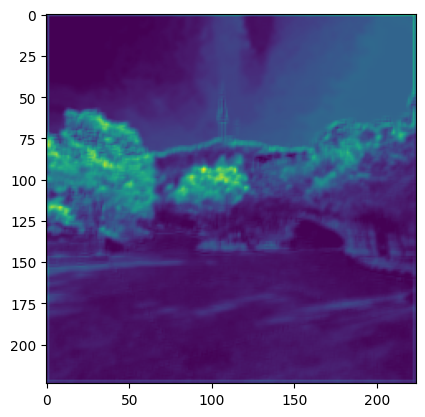

In [46]:
# 이미지의 부분중 밝게 나올수록 필터가 강하게 저용되는 부분임을 알 수 있다.

plt.imshow(contents_true_b1c1[0][:,:,60])

# Gram Matrix
- 스타일 전이 (style Transfer)에서 이미지 스타일을 추출하기 위해 사용하는 핵심 개념
- 필터 (feature map)들이 서로 얼마나 비슷하게 반응하는가?를 계산하는 행렬
- 특징맵 안에 있는 채널들까지의 관계를 계산하는 행렬
- CNN feature map이 있다고 생각한다면,
    - (224,224,64) --> 64개의 필터가 있다는 뜻이고
    - (224,224,64) --> (224*224,64)
- F.T@ F --> (64,50176) @ (50176,64) --> (64,64) 행렬 생성
- 일반 특징맵을 그대로 비교하며 위치까지 비교
- 고흐 그림의 붓터치가 왼쪽 위에 있고, 결과 이미지의 붓터치가 오른쪽 아래에 있으면 다르다고 판단할 수 있음.
- 스타일은 취가 중요한게 아니라, 질감과 패턴이 있느냐가 중요함
-> 결과적으론 Gram Matrix를 사용함

In [47]:
def gram_matrix(x):
    reshape_x = tf.transpose(x,[2,1,0])
    s = tf.shape(reshape_x)
    reshape_x = tf.reshape(reshape_x, (s[0],s[1]*s[2]))
    reshape_x_t = tf.transpose(reshape_x)

    dot = tf.matmul(reshape_x,reshape_x_t)
    dot = tf.cast(dot,dtype='float32')
    dot = dot/tf.cast(tf.shape(reshape_x)[0],tf.float32)/tf.cast(tf.shape(reshape_x)[1],tf.float32)
    return dot

gram_matrix(contents_true_b3c3[0])

<tf.Tensor: shape=(256, 256), dtype=float32, numpy=
array([[670.92145   , 300.26096   ,  29.787085  , ...,  79.89166   ,
         32.275715  ,  33.509777  ],
       [300.26096   , 677.0718    ,  38.13791   , ...,  76.14999   ,
         61.72676   ,  23.603842  ],
       [ 29.787085  ,  38.13791   ,  61.700882  , ...,  18.556425  ,
          0.7200206 ,   0.76897454],
       ...,
       [ 79.89166   ,  76.14999   ,  18.556425  , ..., 184.72241   ,
         18.259306  ,   1.3974121 ],
       [ 32.275715  ,  61.72676   ,   0.7200206 , ...,  18.259306  ,
         94.48031   ,   5.900126  ],
       [ 33.509777  ,  23.603842  ,   0.76897454, ...,   1.3974121 ,
          5.900126  ,  25.236694  ]], dtype=float32)>

In [48]:
# 스타일 변환을 적용할 이미지
input_image = cv2.imread('dataset/GAN/contents.jpg')
input_image = cv2.resize(input_image,(224,224))

In [49]:
img_avi = np.zeros((224,224,3))
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
fcc = cv2.VideoWriter_fourcc(*'DIVX')
out = cv2.VideoWriter('style_transfer.avi',fcc,10.0,(224,224))

for epoch in range(200):
    input_image = tf.reshape(input_image,(-1,224,224,3))
    input_image = tf.cast(input_image,dtype='float32')
    input_image = tf.Variable(input_image,dtype = tf.float32)

    with tf.GradientTape() as tape:
        b1c1, b2c2, b3c3 , b4c3 = style_transfer_model(input_image)
        s_loss_1 = tf.stop_gradient(gram_matrix(style_true_b1c1[0]))-gram_matrix(b1c1[-0])
        s_loss_1 = tf.reduce_mean(tf.square(s_loss_1))
        s_loss_2 = tf.stop_gradient(gram_matrix(style_true_b2c2[0]))-gram_matrix(b2c2[-0])
        s_loss_2 = tf.reduce_mean(tf.square(s_loss_2))
        s_loss_3 = tf.stop_gradient(gram_matrix(style_true_b3c3[0]))-gram_matrix(b3c3[-0])
        s_loss_3 = tf.reduce_mean(tf.square(s_loss_3))
        s_loss_4 = tf.stop_gradient(gram_matrix(style_true_b4c3[0]))-gram_matrix(b4c3[-0])
        s_loss_4 = tf.reduce_mean(tf.square(s_loss_4))


1
s_loss tf.Tensor(1016705.06, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

2
s_loss tf.Tensor(976993.5, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

3
s_loss tf.Tensor(935924.6, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

4
s_loss tf.Tensor(893987.06, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

5
s_loss tf.Tensor(851768.25, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

6
s_loss tf.Tensor(809957.75, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

7
s_loss tf.Tensor(768957.8, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

8
s_loss tf.Tensor(728980.3, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

9
s_loss tf.Tensor(690103.8, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

10
s

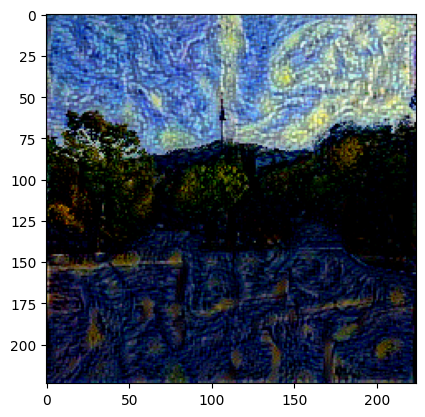

In [50]:
img_avi = np.zeros((224,224,3))
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
fcc = cv2.VideoWriter_fourcc(*'DIVX')
out = cv2.VideoWriter('style_transfer.avi',fcc,10.0,(224,224))

for epoch in range(200):
    input_image = tf.reshape(input_image,(-1,224,224,3))
    input_image = tf.cast(input_image,dtype='float32')
    input_image = tf.Variable(input_image,dtype = tf.float32)

    with tf.GradientTape() as tape:
        b1c1, b2c2, b3c3 , b4c3 = style_transfer_model(input_image)
        s_loss_1 = tf.stop_gradient(gram_matrix(style_true_b1c1[0]))-gram_matrix(b1c1[-0])
        s_loss_1 = tf.reduce_mean(tf.square(s_loss_1))
        s_loss_2 = tf.stop_gradient(gram_matrix(style_true_b2c2[0]))-gram_matrix(b2c2[-0])
        s_loss_2 = tf.reduce_mean(tf.square(s_loss_2))
        s_loss_3 = tf.stop_gradient(gram_matrix(style_true_b3c3[0]))-gram_matrix(b3c3[-0])
        s_loss_3 = tf.reduce_mean(tf.square(s_loss_3))
        s_loss_4 = tf.stop_gradient(gram_matrix(style_true_b4c3[0]))-gram_matrix(b4c3[-0])
        s_loss_4 = tf.reduce_mean(tf.square(s_loss_4))

        c_loss_1 = contents_true_b1c1
        c_loss_1 = tf.reduce_mean(tf.square(c_loss_1))
        c_loss_2 = contents_true_b2c2
        c_loss_2 = tf.reduce_mean(tf.square(c_loss_2))
        c_loss_3 = contents_true_b3c3
        c_loss_3 = tf.reduce_mean(tf.square(c_loss_3))
        c_loss_4 = contents_true_b4c3
        c_loss_4 = tf.reduce_mean(tf.square(c_loss_4))

        s_loss = (s_loss_1+s_loss_2+s_loss_3+s_loss_4)
        c_loss = (c_loss_1 + c_loss_2 + c_loss_3 + c_loss_4) / 4.0
        loss = s_loss * 10.0 + c_loss

    grad = tape.gradient(loss,input_image)
    opt.apply_gradients([(grad,input_image)])
    input_image = tf.cast(input_image,dtype=tf.int32)
    input_image = tf.clip_by_value(input_image,0,255)
    img_avi = input_image.numpy()[0]

    if ((epoch+0)%10==0):
        cv2.imwrite('{}.jpg'.format(epoch),img_avi)
    out.write(np.uint8(img_avi))
    print()
    print(epoch+1)
    print('s_loss',s_loss)
    print('c_loss_3',c_loss_3)
    
plt.imshow(input_image[0][:,:,::-1])
out.release()
cv2.destroyAllWindows()

# 과제

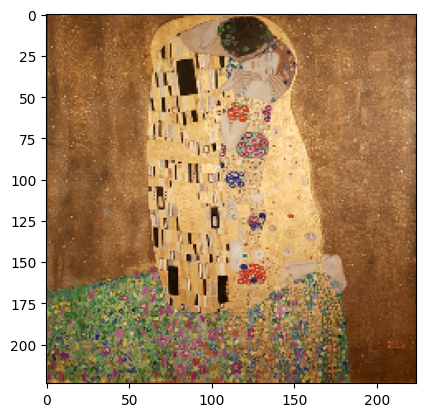

In [51]:
style = cv2.imread('dataset/GAN/kiss.jpg')
style = cv2.resize(style,(224,224))
plt.imshow(cv2.cvtColor(style,cv2.COLOR_BGR2RGB))

In [52]:
# VGG16을 이용해서 이미지의 중간 특징맵을 뽑아낼려고 함.

vgg_model = tf.keras.applications.VGG16(input_shape=(224,224,3),
                                        include_top = False,
                                        weights='imagenet')
vgg_model.trainable = False

In [53]:
# VGG16 중간층 4개의 출력만 가져온다.
# block1 (얕은 층) : 간단한 질감, 선, 색
# block2,3 (중간 층) : 패턴, 모양, 질감
# block4 (깊은 층) : 복잡한, 구조, 형태

style_transfer_model = tf.keras.Model(
    inputs=vgg_model.input,
    outputs=[
        vgg_model.get_layer(name="block1_conv2").output,
        vgg_model.get_layer(name="block2_conv2").output,
        vgg_model.get_layer(name="block3_conv3").output,
        vgg_model.get_layer(name="block4_conv3").output
    ]
)

style_transfer_model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

In [54]:
style_true_b1c1 , style_true_b2c2 , style_true_b3c3 , style_true_b4c3 = style_transfer_model.predict(
    np.reshape(style, (-1,224,224,3)))

style_true_b1c1.shape

1/1 [==============================] - 0s 80ms/step


(1, 224, 224, 64)

In [55]:
def gram_matrix(x):
    reshape_x = tf.transpose(x,[2,1,0])
    s = tf.shape(reshape_x)
    reshape_x = tf.reshape(reshape_x, (s[0],s[1]*s[2]))
    reshape_x_t = tf.transpose(reshape_x)

    dot = tf.matmul(reshape_x,reshape_x_t)
    dot = tf.cast(dot,dtype='float32')
    dot = dot/tf.cast(tf.shape(reshape_x)[0],tf.float32)/tf.cast(tf.shape(reshape_x)[1],tf.float32)
    return dot

gram_matrix(contents_true_b3c3[0])

<tf.Tensor: shape=(256, 256), dtype=float32, numpy=
array([[670.92145   , 300.26096   ,  29.787085  , ...,  79.89166   ,
         32.275715  ,  33.509777  ],
       [300.26096   , 677.0718    ,  38.13791   , ...,  76.14999   ,
         61.72676   ,  23.603842  ],
       [ 29.787085  ,  38.13791   ,  61.700882  , ...,  18.556425  ,
          0.7200206 ,   0.76897454],
       ...,
       [ 79.89166   ,  76.14999   ,  18.556425  , ..., 184.72241   ,
         18.259306  ,   1.3974121 ],
       [ 32.275715  ,  61.72676   ,   0.7200206 , ...,  18.259306  ,
         94.48031   ,   5.900126  ],
       [ 33.509777  ,  23.603842  ,   0.76897454, ...,   1.3974121 ,
          5.900126  ,  25.236694  ]], dtype=float32)>

In [56]:
# 스타일 변환을 적용할 이미지
input_image = cv2.imread('dataset/GAN/contents.jpg')
input_image = cv2.resize(input_image,(224,224))

In [57]:
img_avi = np.zeros((224,224,3))
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
fcc = cv2.VideoWriter_fourcc(*'DIVX')
out = cv2.VideoWriter('style_transfer.avi',fcc,10.0,(224,224))

for epoch in range(200):
    input_image = tf.reshape(input_image,(-1,224,224,3))
    input_image = tf.cast(input_image,dtype='float32')
    input_image = tf.Variable(input_image,dtype = tf.float32)

    with tf.GradientTape() as tape:
        b1c1, b2c2, b3c3 , b4c3 = style_transfer_model(input_image)
        s_loss_1 = tf.stop_gradient(gram_matrix(style_true_b1c1[0]))-gram_matrix(b1c1[-0])
        s_loss_1 = tf.reduce_mean(tf.square(s_loss_1))
        s_loss_2 = tf.stop_gradient(gram_matrix(style_true_b2c2[0]))-gram_matrix(b2c2[-0])
        s_loss_2 = tf.reduce_mean(tf.square(s_loss_2))
        s_loss_3 = tf.stop_gradient(gram_matrix(style_true_b3c3[0]))-gram_matrix(b3c3[-0])
        s_loss_3 = tf.reduce_mean(tf.square(s_loss_3))
        s_loss_4 = tf.stop_gradient(gram_matrix(style_true_b4c3[0]))-gram_matrix(b4c3[-0])
        s_loss_4 = tf.reduce_mean(tf.square(s_loss_4))


1
s_loss tf.Tensor(1508161.8, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

2
s_loss tf.Tensor(1470465.9, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

3
s_loss tf.Tensor(1432572.0, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

4
s_loss tf.Tensor(1394734.0, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

5
s_loss tf.Tensor(1356964.1, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

6
s_loss tf.Tensor(1319618.1, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

7
s_loss tf.Tensor(1283209.1, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

8
s_loss tf.Tensor(1247958.0, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)

9
s_loss tf.Tensor(1213881.2, shape=(), dtype=float32)
c_loss_3 tf.Tensor(163278.19, shape=(), dtype=float32)



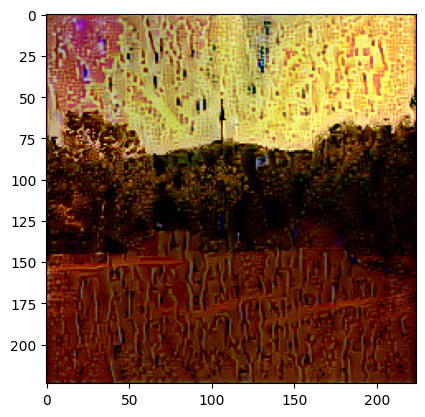

In [58]:
img_avi = np.zeros((224,224,3))
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
fcc = cv2.VideoWriter_fourcc(*'DIVX')
out = cv2.VideoWriter('style_transfer.avi',fcc,10.0,(224,224))

for epoch in range(200):
    input_image = tf.reshape(input_image,(-1,224,224,3))
    input_image = tf.cast(input_image,dtype='float32')
    input_image = tf.Variable(input_image,dtype = tf.float32)

    with tf.GradientTape() as tape:
        b1c1, b2c2, b3c3 , b4c3 = style_transfer_model(input_image)
        s_loss_1 = tf.stop_gradient(gram_matrix(style_true_b1c1[0]))-gram_matrix(b1c1[-0])
        s_loss_1 = tf.reduce_mean(tf.square(s_loss_1))
        s_loss_2 = tf.stop_gradient(gram_matrix(style_true_b2c2[0]))-gram_matrix(b2c2[-0])
        s_loss_2 = tf.reduce_mean(tf.square(s_loss_2))
        s_loss_3 = tf.stop_gradient(gram_matrix(style_true_b3c3[0]))-gram_matrix(b3c3[-0])
        s_loss_3 = tf.reduce_mean(tf.square(s_loss_3))
        s_loss_4 = tf.stop_gradient(gram_matrix(style_true_b4c3[0]))-gram_matrix(b4c3[-0])
        s_loss_4 = tf.reduce_mean(tf.square(s_loss_4))

        c_loss_1 = contents_true_b1c1
        c_loss_1 = tf.reduce_mean(tf.square(c_loss_1))
        c_loss_2 = contents_true_b2c2
        c_loss_2 = tf.reduce_mean(tf.square(c_loss_2))
        c_loss_3 = contents_true_b3c3
        c_loss_3 = tf.reduce_mean(tf.square(c_loss_3))
        c_loss_4 = contents_true_b4c3
        c_loss_4 = tf.reduce_mean(tf.square(c_loss_4))

        s_loss = (s_loss_1+s_loss_2+s_loss_3+s_loss_4)
        c_loss = (c_loss_1 + c_loss_2 + c_loss_3 + c_loss_4) / 4.0
        loss = s_loss * 10.0 + c_loss

    grad = tape.gradient(loss,input_image)
    opt.apply_gradients([(grad,input_image)])
    input_image = tf.cast(input_image,dtype=tf.int32)
    input_image = tf.clip_by_value(input_image,0,255)
    img_avi = input_image.numpy()[0]

    if ((epoch+0)%10==0):
        cv2.imwrite('{}.jpg'.format(epoch),img_avi)
    out.write(np.uint8(img_avi))
    print()
    print(epoch+1)
    print('s_loss',s_loss)
    print('c_loss_3',c_loss_3)
    
plt.imshow(input_image[0][:,:,::-1])
out.release()
cv2.destroyAllWindows()